# Análise Exploratória

-> O objetivo dessa etapa é compreender e analisar a estrutura dos dados, buscamos identificar padrões, relações, outliers, etc.

-> Focaremos a análise no conjunto de dados de treino (`df_treino`)

-> Nosso objetivo é também entender features que podem ser analisadas para um modelo linear e não linear

In [1]:
# Importando bibliotecas dessa análise
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

# Configuração de estilo para os gráficos 
sns.set_theme(style="whitegrid")

# Ignorar avisos 
import warnings
warnings.filterwarnings('ignore')

# Definindo o diretório 
caminho = os.getcwd()

print(os.getcwd())

/home/caua/Área de trabalho/Data Science/Projetos/Projeto_3/Prediction_V2


## 1.1 Carregamento e Inspeção Inicial dos Dados

-> Importando os conjuntos de dados de treino e teste e realizar uma rápida inspeção para entender as dimensões dos arquivos e como os dados estão distibuídos com relação a tipos (numéricos,categóricos,etc)

-> `df_treino` na pasta arquivos há um arquivo chamado: data_description, em que você pode verificar, com base no desafio do kagle, as definições de cada coluna.

In [2]:
df_teste = pd.read_csv(os.path.join(caminho, "arquivos", "test.csv"))

df_treino = pd.read_csv(os.path.join(caminho, "arquivos", "train.csv"))


display(df_teste.head())

display(df_teste.info())

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,...,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
3,1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
4,1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,...,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal


<class 'pandas.DataFrame'>
RangeIndex: 1459 entries, 0 to 1458
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1459 non-null   int64  
 1   MSSubClass     1459 non-null   int64  
 2   MSZoning       1455 non-null   str    
 3   LotFrontage    1232 non-null   float64
 4   LotArea        1459 non-null   int64  
 5   Street         1459 non-null   str    
 6   Alley          107 non-null    str    
 7   LotShape       1459 non-null   str    
 8   LandContour    1459 non-null   str    
 9   Utilities      1457 non-null   str    
 10  LotConfig      1459 non-null   str    
 11  LandSlope      1459 non-null   str    
 12  Neighborhood   1459 non-null   str    
 13  Condition1     1459 non-null   str    
 14  Condition2     1459 non-null   str    
 15  BldgType       1459 non-null   str    
 16  HouseStyle     1459 non-null   str    
 17  OverallQual    1459 non-null   int64  
 18  OverallCond    1459

None

In [3]:
# Contagem e separação das variáveis por tipo de dado
colunas_categoricas = df_treino.select_dtypes(include=['object']).columns
colunas_numericas = df_treino.select_dtypes(include=[np.number]).columns

display("=== Resumo dos Tipos de Variáveis ===")
print(f"Total de variáveis: {df_treino.shape[1]}")
print(f"Variáveis Categóricas (object): {len(colunas_categoricas)}")
print(f"Variáveis Numéricas (int/float): {len(colunas_numericas)} \n")

'=== Resumo dos Tipos de Variáveis ==='

Total de variáveis: 81
Variáveis Categóricas (object): 43
Variáveis Numéricas (int/float): 38 



## 1.2 Análise inicial do Dataframe

-> Numa análise inicial Veja que há muitos dados em formato de string. No futuro tratamento desses dados, afinal o dataset possui diversas variáveis categóricas ordinais que podem futuramente sofrer encondings para treinar o modelo.


## 2.1 Estatística Descritiva da Variável Alvo (`SalePrice`)

Realizamos uma análise quantitativa univariada dos preços de venda dos imóveis, calculando medidas de tendência central (Média, Mediana), dispersão (Desvio Padrão, IQR) e Quartis (1º e 3º Quartis).

O objetivo é obter um diagnóstico inicial do comportamento e da distribuição dos dados, fornecendo a base que será  aprofundada nas etapas futuras

In [4]:
# Cálculo das estatísticas descritivas do SalePrice
sale_price = df_treino['SalePrice']

metricas = {
    'Métrica': [
        'Média', 
        'Mediana', 
        'Desvio Padrão', 
        'Mínimo', 
        '1º Quartil (Q1 - 25%)', 
        '3º Quartil (Q3 - 75%)', 
        'Intervalo Interquartil (IQR)', 
        'Máximo',
        'Assimetria (Skewness)', 
        'Curtose (Kurtosis)'
    ],
    'Valor': [
        f"${sale_price.mean():,.2f}",
        f"${sale_price.median():,.2f}",
        f"${sale_price.std():,.2f}",
        f"${sale_price.min():,.2f}",
        f"${sale_price.quantile(0.25):,.2f}",
        f"${sale_price.quantile(0.75):,.2f}",
        f"${(sale_price.quantile(0.75) - sale_price.quantile(0.25)):,.2f}",
        f"${sale_price.max():,.2f}",
        f"{sale_price.skew():.2f}",
        f"{sale_price.kurt():.2f}"
    ]
}

# Apresentação em formato de tabela limpa
df_resumo_estatistico = pd.DataFrame(metricas)
display(df_resumo_estatistico)

,Métrica,Valor
0,Média,"$180,921.20"
1,Mediana,"$163,000.00"
2,Desvio Padrão,"$79,442.50"
3,Mínimo,"$34,900.00"
4,1º Quartil (Q1 - 25%),"$129,975.00"
5,3º Quartil (Q3 - 75%),"$214,000.00"
6,Intervalo Interquartil (IQR),"$84,025.00"
7,Máximo,"$755,000.00"
8,Assimetria (Skewness),1.88
9,Curtose (Kurtosis),6.54


## 2.2 Análise Visual da Distribuição (`SalePrice`) e Teste de Normalidade

Plotamos o histograma dos preços de venda com a curva de densidade real (KDE) sobreposta à curva normal teórica ($\mu$ e $\sigma$ ajustados aos dados). 

Vamos analisar aspectos visuais dos gráficos buscando entender possíveis padrões

Vamos analisar as transformações log e raiz pra observar possíveis padrões


------------------------------------------------------------------------------------------------------------

### (1) Gerando um gráfico histograma (com bins baseados na regra de sturge) juntamente com seu boxplot e demais medidas estatísticas básicas

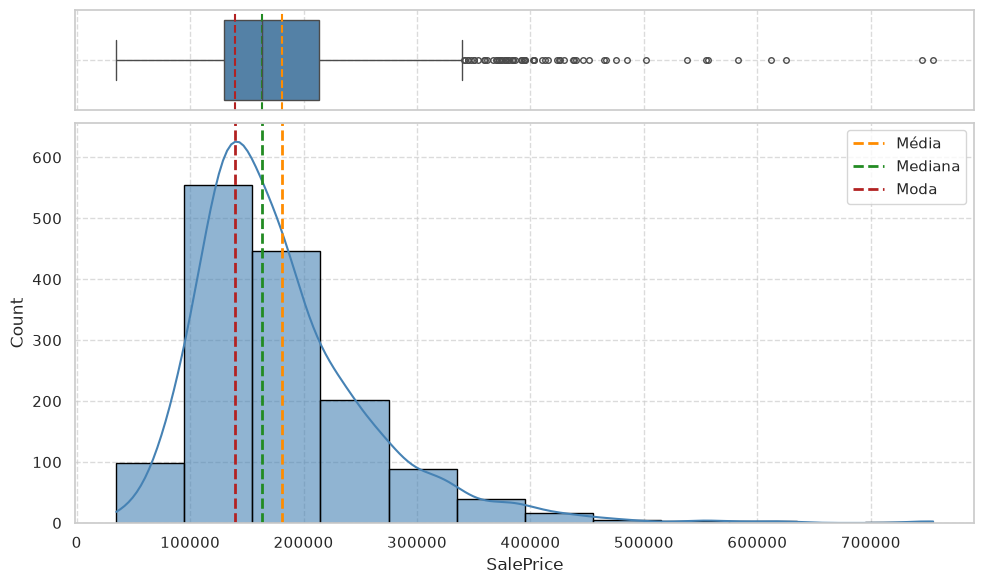

In [5]:



# Definição dos dados e cálculo das medidas de tendência central
preco = df_treino['SalePrice']
media = preco.mean()
mediana = preco.median()
moda = preco.mode()[0] # mode() retorna uma Series, pegamos o primeiro valor

# Configuração da figura com 2 subplots compartilhando o eixo X
fig, (ax_box, ax_hist) = plt.subplots(2, 1, sharex=True, gridspec_kw={"height_ratios": (1, 4)}, figsize=(10, 6))

# 1. Plot do Boxplot (Superior)
sns.boxplot(x=preco, ax=ax_box, color='steelblue', fliersize=4)
ax_box.axvline(media, color='darkorange', linestyle='--')
ax_box.axvline(mediana, color='forestgreen', linestyle='--')
ax_box.axvline(moda, color='firebrick', linestyle='--')
ax_box.set(xlabel='') # Remove título do eixo x no boxplot
ax_box.grid(True, linestyle='--', alpha=0.7)

# 2. Plot do Histograma com KDE (Inferior) utilizando a regra de Sturges
sns.histplot(x=preco, bins='sturges', kde=True, ax=ax_hist, color='steelblue', edgecolor='black', alpha=0.6)

# Adição das linhas verticais estatísticas no histograma
ax_hist.axvline(media, color='darkorange', linestyle='--', linewidth=2, label='Média')
ax_hist.axvline(mediana, color='forestgreen', linestyle='--', linewidth=2, label='Mediana')
ax_hist.axvline(moda, color='firebrick', linestyle='--', linewidth=2, label='Moda')

# Formatação final
ax_hist.legend(frameon=True, fontsize=11)
ax_hist.set_xlabel('SalePrice', fontsize=12)
ax_hist.set_ylabel('Count', fontsize=12)
ax_hist.grid(True, linestyle='--', alpha=0.7)

# Ajuste de layout para unir os dois gráficos como na imagem de referência
plt.tight_layout()
plt.subplots_adjust(hspace=0.05) 
plt.show()

> **Diagnóstico Exploratório e Pré-Análise da Variável Alvo (`SalePrice`):**
> 
> 1. **Alta Concentração na Faixa Central:** Visivelmente, observa-se que a faixa de imóveis no entorno da média/mediana é grande e densa, com a esmagadora maioria das negociações concentrada entre **\$129.975,00 e \$214.000,00** (faixa interquartil - IQR de \$84.025,00).
> 
> 2. **Clara Assimetria Positiva e Curtose Elevada:** O arranjo bem definido $\text{Moda} < \text{Mediana} < \text{Média}$ (Moda $< \$163.000,00 < \$180.921,20$) e a cauda longa estendida à direita ratificam os índices numéricos de **Assimetria (1.88)** e **Curtose (6.54)**, configurando uma distribuição fortemente assimétrica à direita e leptocúrtica.
> 
> 3. **Presença Marcante de Outliers Unidirecionais:** O boxplot superior evidencia uma dispersão acentuada de valores atípicos univariados à direita, chegando a transações de até **\$755.000,00**. Esses poucos imóveis de altíssimo padrão puxam a média para cima em relação à mediana.


### (1) Gerando um gráfico histograma (com bins baseados na regra de sturge) juntamente com seu boxplot e demais medidas estatísticas básicas

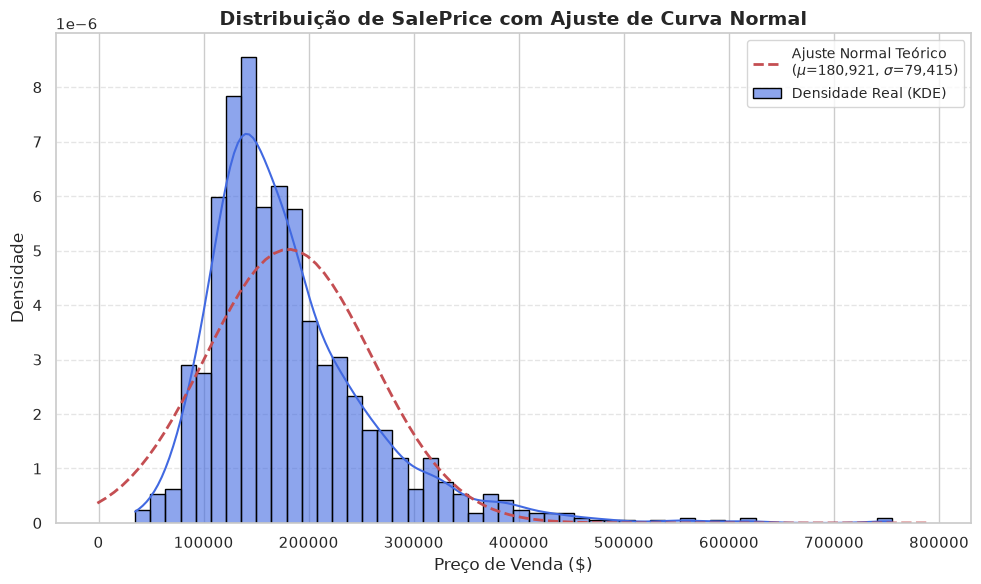

In [6]:

# Configuração da figura
plt.figure(figsize=(10, 6))



# Histograma com estimativa de densidade de Kernel (KDE real)
sns.histplot(
    df_treino['SalePrice'], 
    kde=True, 
    stat="density", 
    color='royalblue', 
    bins=50, 
    edgecolor='black', 
    alpha=0.6, 
    label='Densidade Real (KDE)'
)

#Ajuste e plotagem da Curva Normal Teórica

mu, std = stats.norm.fit(df_treino['SalePrice']) #ajuste normal
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = stats.norm.pdf(x, mu, std)

plt.plot(
    x, p, 'r--', linewidth=2, 
    label=f'Ajuste Normal Teórico\n($\mu$={mu:,.0f}, $\sigma$={std:,.0f})'
)

# Formatação e Títulos
plt.title('Distribuição de SalePrice com Ajuste de Curva Normal', fontsize=14, fontweight='bold')
plt.xlabel('Preço de Venda ($)', fontsize=12)
plt.ylabel('Densidade', fontsize=12)
plt.legend(frameon=True, fontsize=10)
plt.grid(axis='y', alpha=0.5, linestyle='--')

plt.tight_layout()
plt.show()

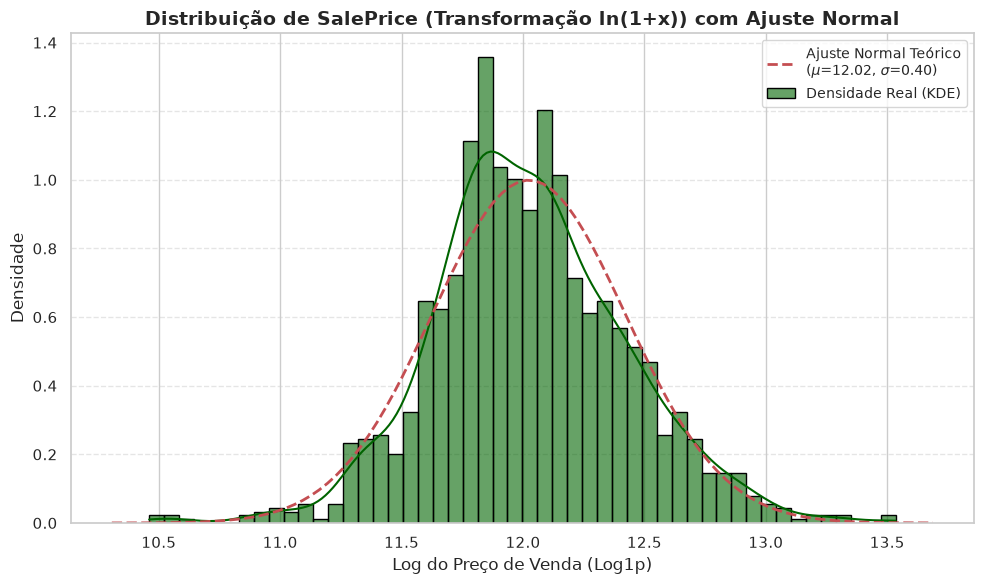

In [7]:
# Aplicação da transformação logarítmica (log1p para lidar com estabilidade numérica)
saleprice_log = np.log1p(df_treino['SalePrice'])

# Configuração da figura
plt.figure(figsize=(10, 6))

# Histograma com estimativa de densidade de Kernel (KDE real) - Cor verde
sns.histplot(
    saleprice_log, 
    kde=True, 
    stat="density", 
    color='darkgreen', 
    bins=50, 
    edgecolor='black', 
    alpha=0.6, 
    label='Densidade Real (KDE)'
)

# Ajuste e plotagem da Curva Normal Teórica usando os dados transformados
mu, std = stats.norm.fit(saleprice_log) 
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = stats.norm.pdf(x, mu, std)

plt.plot(
    x, p, 'r--', linewidth=2, 
    label=f'Ajuste Normal Teórico\n($\mu$={mu:,.2f}, $\sigma$={std:,.2f})'
)

# Formatação e Títulos atualizados
plt.title('Distribuição de SalePrice (Transformação ln(1+x)) com Ajuste Normal', fontsize=14, fontweight='bold')
plt.xlabel('Log do Preço de Venda (Log1p)', fontsize=12)
plt.ylabel('Densidade', fontsize=12)
plt.legend(frameon=True, fontsize=10)
plt.grid(axis='y', alpha=0.5, linestyle='--')

plt.tight_layout()
plt.show()

# log(1+x) --> logp

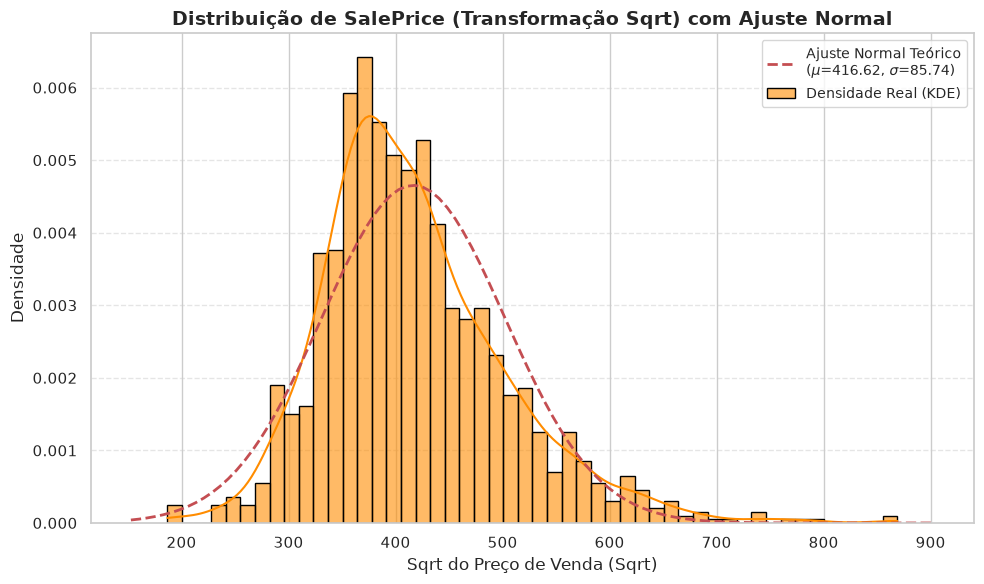

In [8]:
# Aplicação da transformação logarítmica (log1p para lidar com estabilidade numérica)
saleprice_sqrt = np.sqrt(df_treino['SalePrice'])

# Configuração da figura
plt.figure(figsize=(10, 6))

# Histograma com estimativa de densidade de Kernel (KDE real) - Cor verde
sns.histplot(
    saleprice_sqrt, 
    kde=True, 
    stat="density", 
    color='darkorange', 
    bins=50, 
    edgecolor='black', 
    alpha=0.6, 
    label='Densidade Real (KDE)'
)

# Ajuste e plotagem da Curva Normal Teórica usando os dados transformados
mu, std = stats.norm.fit(saleprice_sqrt) 
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = stats.norm.pdf(x, mu, std)

plt.plot(
    x, p, 'r--', linewidth=2, 
    label=f'Ajuste Normal Teórico\n($\mu$={mu:,.2f}, $\sigma$={std:,.2f})'
)

# Formatação e Títulos atualizados
plt.title('Distribuição de SalePrice (Transformação Sqrt) com Ajuste Normal', fontsize=14, fontweight='bold')
plt.xlabel('Sqrt do Preço de Venda (Sqrt)', fontsize=12)
plt.ylabel('Densidade', fontsize=12)
plt.legend(frameon=True, fontsize=10)
plt.grid(axis='y', alpha=0.5, linestyle='--')

plt.tight_layout()
plt.show()

> ### Análise Visual da Distribuição e Efeito da Transformação Log**
>
> * **Comportamento da Distribuição Original (KDE vs. Normal):**
>   * **Concentração de Vendas:** A curva empírica azul (KDE) da variável original apresenta um pico mais elevado e deslocado para a esquerda em relação à curva normal teórica (linha tracejada vermelha), demonstrando que a grande maioria das transações ocorre na faixa de **\$130k a \$170k**, patamar inferior à média global (\~\$181k).
>   * **Assimetria e Curtose:** A cauda longa estendida à direita revela um volume reduzido de imóveis de altíssimo padrão (acima de **\$400k**), confirmando a **forte assimetria positiva** e o **caráter leptocúrtico** (pico agudo e caudas pesadas) diagnosticados nas estatísticas descritivas.
>
> * **Impacto da Transformação Logarítmica (`log1p`):**
>   * **Aproximação Gaussiana:** No gráfico transformado (histograma verde), a curva empírica passa a aderir de forma muito mais fiel à curva normal teórica, comprimindo a cauda longa e reduzindo a dispersão extrema.
>   * **Homocedasticidade:** A escala logarítmica estabiliza a variância dos dados, tornando a distribuição dos preços simétrica e em formato de sino.
>
> * **Conclusão e Justificativa para Modelagem:**
>   * **Mitigação de Overfitting:** Reduz a penalização excessiva de erros quadráticos em casas de luxo, evitando que modelos baseados em árvores (Random Forest, Gradient Boosting, XGBoost) criem divisões profundas apenas para acomodar casos atípicos.
>   * **Viabilização de Algoritmos Lineares:** Modelos lineares (Ridge, Lasso, ElasticNet) exigem que os resíduos sigam uma distribuição aproximadamente normal; a transformação `log1p` satisfaz essa premissa teórica e melhora a capacidade de generalização de modelos lineares e não-lineares.

## 2.3 Análise de Outliers com Boxplot

Para complementar a análise de distribuição, utilizamos o diagrama de caixa (*Boxplot*) de modo a poder analisar quartis e outliers.


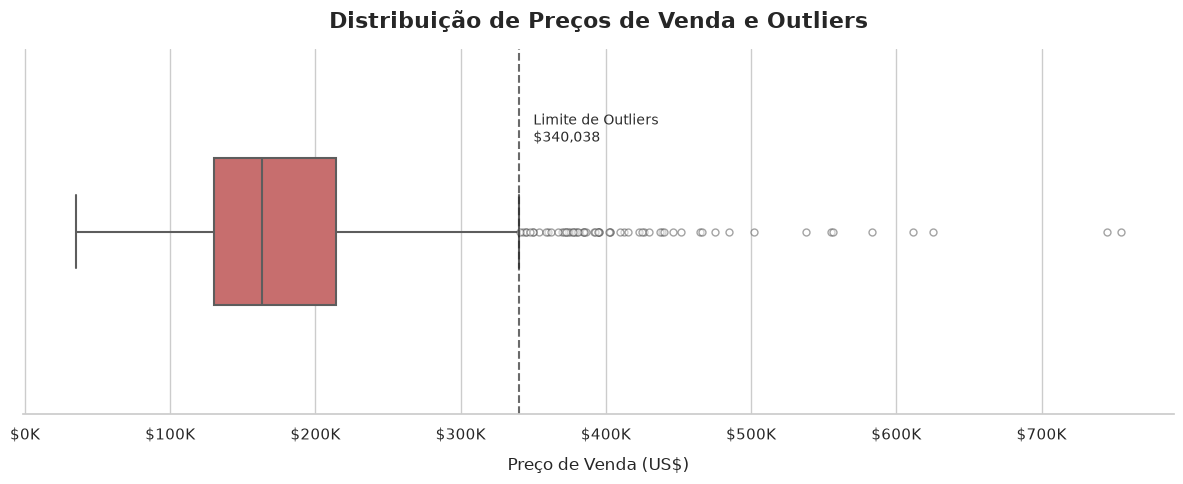

Linha de corte para Outliers Superiores: $340,037.50
Total de imóveis considerados Outliers: 61 casas


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

# 1. Configuração de estilo do Seaborn para um visual mais limpo
sns.set_theme(style="whitegrid")

# 2. Cálculos estatísticos para os outliers
Q1 = df_treino['SalePrice'].quantile(0.25)
Q3 = df_treino['SalePrice'].quantile(0.75)
IQR = Q3 - Q1
limite_superior = Q3 + 1.5 * IQR
qtd_outliers = len(df_treino[df_treino['SalePrice'] > limite_superior])

# 3. Configuração da figura (levemente mais larga e menos alta para focar na horizontal)
plt.figure(figsize=(12, 5))

# 4. Geração do Boxplot com propriedades customizadas
ax = sns.boxplot(
    x=df_treino['SalePrice'], 
    color='#D65F5F',     # Um tom de vermelho/coral mais suave e elegante
    width=0.4,           # Caixa levemente mais fina
    linewidth=1.5,
    flierprops={
        'marker': 'o',
        'markerfacecolor': 'white', 
        'markeredgecolor': '#4A4A4A',
        'alpha': 0.5,    # Transparência nos outliers para não sobrecarregar
        'markersize': 5
    }
)

# 5. Adicionando a linha visual do limite superior
plt.axvline(limite_superior, color='#2B2B2B', linestyle='--', linewidth=1.5, alpha=0.7)

# Anotação em texto indicando o limite no gráfico
plt.text(
    limite_superior + 10000, -0.28, 
    f'Limite de Outliers\n${limite_superior:,.0f}', 
    color='#2B2B2B', fontsize=10, va='center'
)

# 6. Formatação do eixo X (Transformando 200000 em $200K)
formatter = ticker.FuncFormatter(lambda x, pos: f'${x/1000:,.0f}K')
ax.xaxis.set_major_formatter(formatter)

# 7. Formatação de Títulos e Eixos
plt.title('Distribuição de Preços de Venda e Outliers', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Preço de Venda (US$)', fontsize=12, labelpad=10)

# 8. Limpeza do layout (Remoção de bordas e ticks desnecessários)
sns.despine(left=True)
ax.set_yticks([]) # O eixo Y não precisa de marcações em um boxplot horizontal

plt.tight_layout()
plt.show()

# Prints mantidos
print(f"Linha de corte para Outliers Superiores: ${limite_superior:,.2f}")
print(f"Total de imóveis considerados Outliers: {qtd_outliers} casas")

> **Diagnóstico Visual**
> * A caixa vermelha concentra 50% dos dados (IQR). A mediana de (\$163.000), que está visivelmente mais próxima do Q1, confirma a assimetria positiva apontada anteriormente.
> * Os pontos (losangos) à direita do limite representam as **61 casas** vendidas por valores superiores a **\$340.037,50**.
> * **Decisão de Modelagem:** A presença forte desses 61 *outliers* indica que, dependendo do modelo escolhido, pode ser necessário aplicar técnicas de regularização ou remoção dos outliers extremos de modo a não distorcer o modelo

'Tabela com os 15 maiores Fatores de Correlação:'

,SalePrice
SalePrice,1.000000
OverallQual,0.790982
GrLivArea,0.708624
GarageCars,0.640409
GarageArea,0.623431
TotalBsmtSF,0.613581
1stFlrSF,0.605852
FullBath,0.560664
TotRmsAbvGrd,0.533723
YearBuilt,0.522897


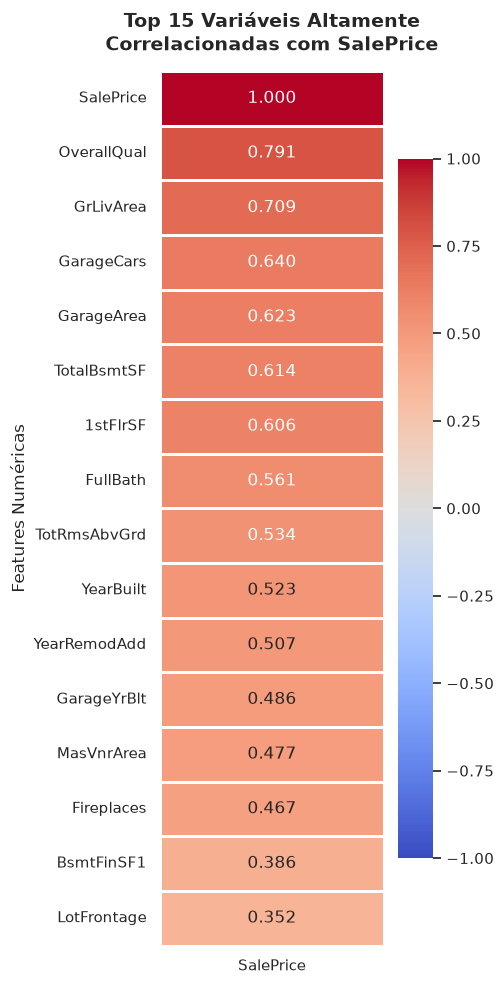

In [10]:
# 1. Selecionar apenas as colunas numéricas
colunas_numericas = df_treino.select_dtypes(include=[np.number])

# 2. Calcular a correlação de todas as variáveis APENAS com o 'SalePrice'
# O uso dos dois colchetes [['SalePrice']] garante que o resultado seja um DataFrame (necessário para o heatmap)
correlacao_saleprice = colunas_numericas.corr()[['SalePrice']]

# 3. Filtrar as 15 maiores correlações (pegamos 16 porque o próprio SalePrice é o 1º, com valor 1.0)
df_top15_corr = correlacao_saleprice.sort_values(by='SalePrice', ascending=False).head(16)

# Exibe o DataFrame limpo
display("Tabela com os 15 maiores Fatores de Correlação:")
display(df_top15_corr)

# 4. Plotar o Heatmap Focado (1 Coluna)
plt.figure(figsize=(5, 10)) # Tamanho ajustado para formato vertical
ax = sns.heatmap(
    df_top15_corr, 
    annot=True,          # Mostra os números
    cmap='coolwarm',     # Paleta divergente
    fmt=".3f",           # 3 casas decimais para maior precisão
    linewidths=1,        # Espaçamento mais visível entre as células
    vmin=-1, vmax=1,     # Fixa a escala térmica (de -1 a 1) para a cor representar a força real
    cbar_kws={"shrink": .8}
)

plt.title('Top 15 Variáveis Altamente\nCorrelacionadas com SalePrice', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Features Numéricas', fontsize=12)
plt.tight_layout()
plt.show()

> ### **Principais Insights: Top 15 Fatores de Correlação com SalePrice**
> 
> 1. **Os Fortes Preditores (O Top 2):** 
>    As variáveis `OverallQual` (0.79) e `GrLivArea` (0.71) lideram isoladas. A nota de qualidade geral e o tamanho da área habitável (acima do nível do solo) são, indiscutivelmente, os fatores que mais ditam o preço de venda de um imóvel.
>
> 2. **Preditores Secundários (A Força do Tamanho e Idade):** 
>    Logo em seguida, observamos um bloco de variáveis relacionadas a espaço extra e idade: tamanho da garagem (`GarageCars` 0.64 / `GarageArea` 0.62), área do porão (`TotalBsmtSF` 0.61) e o ano de construção (`YearBuilt` 0.52). 
>
> 3. **Fortes Sinais de Multicolinearidade (Redundância):**
>    Avaliando esse Top 15, identificamos vários pares de variáveis que "explicam a mesma coisa", o que pode confundir o modelo matemático:
>    * **Garagem:** `GarageCars` e `GarageArea` (correlação mútua historicamente altíssima). É pura lógica espacial: quanto mais carros a garagem comporta, maior a sua área em pés quadrados.
>    * **Tamanho vs. Cômodos:** `GrLivArea` (Área Habitável) e `TotRmsAbvGrd` (Total de Cômodos). Casas com maior área útil inevitavelmente possuem mais cômodos.
>    * **Estrutura da Planta:** `1stFlrSF` (Área do 1º Andar) e `TotalBsmtSF` (Área Total do Porão) costumam ter metragens quase idênticas, já que o primeiro andar fica exatamente sobre o porão na maioria das plantas.
>    * **Idade:** `YearBuilt` (Ano de Construção) e `GarageYrBlt` (Ano da Garagem). Na esmagadora maioria das vezes, a garagem é construída no mesmo ano que a casa.
>
> 4. **Decisão Prática para Modelagem:** 
>    Na próxima etapa de Feature Engineering, será ideal **remover uma variável de cada um desses pares redundantes**. Por exemplo: manter `GarageCars` e descartar `GarageArea`; manter `YearBuilt` e descartar `GarageYrBlt`. Isso diminui a dimensionalidade, reduz o ruído da multicolinearidade e cria um modelo mais leve e assertivo.

## 2.4 Features principais para uma análise linear:

### Redução de Dimensionalidade: Remoção de Features Colineares

Identificou-se forte multicolinearidade com outras variáveis de maior correlação com o preço de venda. Por essa razão, **5 features fserão descartadas**:

* **`GarageArea` (0.62):** Redundante com `GarageCars` (0.64), pois ambas explicam a mesma capacidade da garagem.
* **`TotRmsAbvGrd` (0.53):** Apresenta forte colinearidade com a área habitável total (`GrLivArea` - 0.70).
* **`1stFlrSF` (0.60):** Correlação estrutural quase perfeita com a área do porão diretamente abaixo (`TotalBsmtSF` - 0.61).
* **`GarageYrBlt` (0.48):** Fortemente sincronizada com o ano de construção do imóvel (`YearBuilt` - 0.52).
* **`BsmtFinSF1` (0.38):** Representa apenas uma fração da área do porão, já contemplada pelo total de `TotalBsmtSF` (0.61).

---

### Top 10 Features Selecionadas (Modelagem Linear)

Selecionaremos as 10 variáveis restantes com maior poder preditivo linear:

| Feature | Correlação com o Target | Justificativa |
| :--- | :---: | :--- |
| **`OverallQual`** | **0.79** | Avaliação geral dos materiais e acabamento. |
| **`GrLivArea`** | **0.70** | Área útil habitável acima do nível do solo. |
| **`GarageCars`** | **0.64** | Capacidade da garagem por quantidade de vagas. |
| **`TotalBsmtSF`** | **0.61** | Área total construída do subsolo/porão. |
| **`FullBath`** | **0.56** | Quantidade total de banheiros completos acima do solo. |
| **`YearBuilt`** | **0.52** | Ano de construção original do imóvel. |
| **`YearRemodAdd`** | **0.50** | Ano da última reforma ou modernização realizada. |
| **`MasVnrArea`** | **0.47** | Área de revestimento em alvenaria decorativa. |
| **`Fireplaces`** | **0.46** | Quantidade de lareiras disponíveis no imóvel. |
| **`LotFrontage`** | **0.35** | Comprimento da frente do terreno voltada para a rua. |

## 2.5  Preditores Principais vs. SalePrice

Após identificar `GrLivArea` (Área Habitável) e `OverallQual` (Qualidade Geral) como os principais impulsionadores do preço de venda, vamos visualizar essas relações diretamente. 

Utilizamos um *Scatter Plot* para a variável contínua (área) a fim de identificar tendências e anomalias lógicas, e um *Boxplot* agrupado para a variável ordinal (qualidade) para verificar a progressão dos preços e a dispersão dentro de cada categoria.

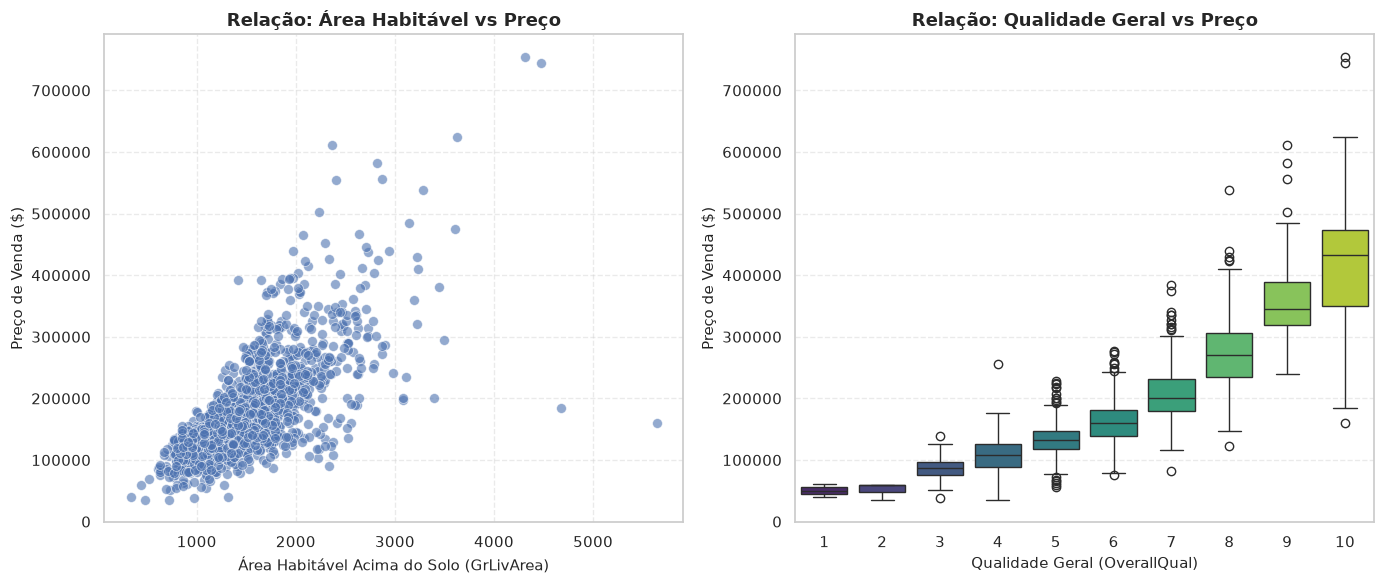

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

# Gráfico 1: Área Habitável vs Preço (Scatter Plot)
plt.subplot(1, 2, 1)
sns.scatterplot(
    x=df_treino['GrLivArea'], 
    y=df_treino['SalePrice'], 
    alpha=0.6, 
    color='b', 
    edgecolor='w', 
    s=50
)
plt.title('Relação: Área Habitável vs Preço', fontsize=13, fontweight='bold')
plt.xlabel('Área Habitável Acima do Solo (GrLivArea)', fontsize=11)
plt.ylabel('Preço de Venda ($)', fontsize=11)
plt.grid(alpha=0.4, linestyle='--')

# Gráfico 2: Qualidade Geral vs Preço (Boxplot)
plt.subplot(1, 2, 2)
sns.boxplot(
    x=df_treino['OverallQual'], 
    y=df_treino['SalePrice'], 
    palette='viridis'
)
plt.title('Relação: Qualidade Geral vs Preço', fontsize=13, fontweight='bold')
plt.xlabel('Qualidade Geral (OverallQual)', fontsize=11)
plt.ylabel('Preço de Venda ($)', fontsize=11)
plt.grid(axis='y', alpha=0.4, linestyle='--')

plt.tight_layout()
plt.show()

> **Insights**
> 
> 1. **Tendência Clara:** No gráfico da direita, fica evidente que o salto de preço é extremamente relevante conforme a qualidade (notas 8, 9 e 10) aumenta, confirmando sua alta correlação.
> 2. **Identificação de Anomalias (Outliers Lógicos):** No gráfico da esquerda, a relação entre Área e Preço forma um cone ascendente. Contudo, há **dois pontos isolados no canto inferior direito** (casas com mais de 4.000 pés quadrados vendidas por preços irrisórios, abaixo de \$200.000). 
> 3. **Decisão de Modelagem:** Esses dois imóveis gigantes e muito baratos representam ruído extremo (provavelmente vendas agrícolas ou atípicas). 
>
> 4. **Remover apenas essas duas linhas** do dataset de treino é altamente recomendado para proteger qualquer modelo de precificação.